# House Tweets — Sentiment & Emotion Analysis

Single-pass pipeline: load → preprocess → score sentiment → score emotions → aggregate → visualize.

**Steps**
1. Imports & config
2. Load & preprocess
3. Sentiment scoring (RoBERTa)
4. Emotion scoring (Hartmann)
5. Save enriched tweets
6. User-level aggregation
7. Visualizations

---
## 0 · Imports & config

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import pipeline
from tqdm import tqdm

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 100)

# ── Paths ──────────────────────────────────────────────────────────────────
HOUSE_TWEETS_CSV  = "/Users/anngo/Documents/GitHub/26-spring-ngo-a/data/congress/x-scraper/tweets_filtered.csv"
SAMPLE_HOUSE_CSV  = "/Users/anngo/Documents/GitHub/26-spring-ngo-a/data/congress/x-scraper/sample_house_full.csv"
ENRICHED_CSV      = "house_tweets_enriched.csv"
USER_SUMMARY_CSV  = "user_sentiment_summary.csv"

# ── Model config ───────────────────────────────────────────────────────────
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
EMOTION_MODEL   = "j-hartmann/emotion-english-distilroberta-base"
BATCH_SIZE      = 32

# ── Visualization config ───────────────────────────────────────────────────
TIME_FREQ     = "M"   # "M" = monthly, "Q" = quarterly
MISSING_COLOR = "lightgrey"

QUARTILE_ORDER = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]

---
## 1 · Load & preprocess

In [3]:
tweets = pd.read_csv(HOUSE_TWEETS_CSV)
sample = pd.read_csv(SAMPLE_HOUSE_CSV)

print(f"Tweets loaded : {len(tweets):,}")
print(f"House members : {len(sample)}")
print(f"Columns       : {list(tweets.columns)}")
tweets.head(3)

Tweets loaded : 438,674
House members : 425
Columns       : ['Account', 'Username', 'Text', 'Created At', 'Retweets', 'Likes', 'Tweet_ID', 'Display_Name']


/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_51985/1873741117.py:1: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets = pd.read_csv(HOUSE_TWEETS_CSV)


,Account,Username,Text,Created At,Retweets,Likes,Tweet_ID,Display_Name
0,mtgreenee,Marjorie Taylor Greene 🇺🇸,https://t.co/xnIOb3V8xI,2024-11-29 00:20:56+00:00,552,3654,1.862291e+18,NaN
1,mtgreenee,Marjorie Taylor Greene 🇺🇸,Congressman John Duarte was winning but after 22 days of...,2024-11-27 12:45:01+00:00,13443,35785,1.861753e+18,NaN
2,mtgreenee,Marjorie Taylor Greene 🇺🇸,@LouisofMonmouth @mikecleere @RealAmVoice @RepMTG @brian...,2024-11-26 13:01:53+00:00,3,8,1.861395e+18,NaN


In [6]:
# Parse dates
tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce")
tweets = tweets.dropna(subset=["Text", "Created At"]).copy()

tweets["handle"] = tweets["Account"].astype(str).str.strip()
tweets["handle"] = tweets["Account"].astype(str).str.strip()

# Preprocess text for models: replace @mentions and URLs
def preprocess(text):
    tokens = []
    for t in str(text).split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)

tweets["clean_text"] = tweets["Text"].apply(preprocess)

print(f"Rows after cleaning: {len(tweets):,}")
tweets[["handle", "Text", "clean_text", "Created At"]].head(3)

Rows after cleaning: 438,674


,handle,Text,clean_text,Created At
0,mtgreenee,https://t.co/xnIOb3V8xI,http,2024-11-29 00:20:56+00:00
1,mtgreenee,Congressman John Duarte was winning but after 22 days of...,Congressman John Duarte was winning but after 22 days of...,2024-11-27 12:45:01+00:00
2,mtgreenee,@LouisofMonmouth @mikecleere @RealAmVoice @RepMTG @brian...,@user @user @user @user @user http,2024-11-26 13:01:53+00:00


In [7]:
# Build handle → quartile + party mapping from sample_house
sample["handle_lower"] = sample["twitter"].str.lower().str.strip()
tweets["handle_lower"] = tweets["handle"].str.lower().str.strip()

meta_cols = ["handle_lower", "official_full", "quartile", "party_code", "state", "pct_small_donors"]
handle_meta = sample[meta_cols].drop_duplicates("handle_lower")

tweets = tweets.merge(handle_meta, on="handle_lower", how="left")

print("Quartile coverage:")
print(tweets["quartile"].value_counts())
unmatched = tweets['quartile'].isna().sum()
print(f"Unmatched handles: {tweets['quartile'].isna().sum():,}")

Quartile coverage:
quartile
Q4 (highest)    116984
Q3              114643
Q2              103466
Q1 (lowest)      96028
Name: count, dtype: int64
Unmatched handles: 7,553


---
## 2 · Sentiment scoring

Runs  on every tweet.
Outputs  (Negative / Neutral / Positive), , and a continuous
 in [−1, +1].

In [8]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512,
)

def run_pipeline(pipe, texts, chunk_size=5000, desc="Scoring"):
    results = []
    for i in tqdm(range(0, len(texts), chunk_size), desc=desc):
        results.extend(pipe(texts[i:i+chunk_size], truncation=True, max_length=512))
    return results

sent_preds = run_pipeline(sentiment_pipe, tweets["clean_text"].tolist(), desc="Sentiment")

tweets["label"]      = [p["label"].lower().strip() for p in sent_preds]
tweets["confidence"] = [p["score"]                 for p in sent_preds]

def sentiment_score(label, conf):
    if label == "negative": return -conf
    if label == "positive": return  conf
    return 0.0

tweets["sentiment_score"] = [
    sentiment_score(l, c) for l, c in zip(tweets["label"], tweets["confidence"])
]

print(tweets[["label", "confidence", "sentiment_score"]].describe().round(3))
print("Label breakdown:")
print(tweets["label"].value_counts())

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Sentiment: 100%|██████████| 88/88 [8:52:09<00:00, 362.83s/it]   


       confidence  sentiment_score
count  438674.000       438674.000
mean        0.805            0.216
std         0.158            0.710
min         0.336           -0.963
25%         0.678           -0.534
50%         0.850            0.000
75%         0.945            0.943
max         0.993            0.993
Label breakdown:
label
positive    211705
negative    117187
neutral     109782
Name: count, dtype: int64


---
## 3 · Emotion scoring

Runs , extracting anger, fear, and joy
scores (each in [0, 1]) per tweet.

In [9]:
emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    return_all_scores=True,
    truncation=True,
)

emo_preds = run_pipeline(emotion_pipe, tweets["clean_text"].tolist(), desc="Emotions")

def extract_score(result, target):
    for item in result:
        if item["label"].lower() == target:
            return item["score"]
    return 0.0

for emotion in ["anger", "fear", "joy", "disgust", "sadness", "surprise", "neutral"]:
    tweets[emotion] = [extract_score(r, emotion) for r in emo_preds]

print(tweets[["anger", "fear", "joy", "disgust", "sadness"]].describe().round(3))

/Users/anngo/anaconda3/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:105: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Emotions: 100%|██████████| 88/88 [3:24:05<00:00, 139.15s/it]  


            anger        fear         joy     disgust     sadness
count  438674.000  438674.000  438674.000  438674.000  438674.000
mean        0.116       0.200       0.294       0.043       0.072
std         0.201       0.299       0.373       0.126       0.174
min         0.000       0.000       0.000       0.000       0.000
25%         0.008       0.006       0.006       0.001       0.006
50%         0.024       0.032       0.049       0.003       0.014
75%         0.112       0.277       0.665       0.017       0.040
max         0.995       0.996       0.995       0.992       0.993


---
## 4 · Save enriched tweets

In [10]:
tweets.to_csv(ENRICHED_CSV, index=False)
print(f"Saved → {ENRICHED_CSV}  ({len(tweets):,} rows, {len(tweets.columns)} columns)")
tweets.head(3)

Saved → house_tweets_enriched.csv  (438,674 rows, 26 columns)


,Account,Username,Text,Created At,Retweets,Likes,Tweet_ID,Display_Name,handle,clean_text,...,label,confidence,sentiment_score,anger,fear,joy,disgust,sadness,surprise,neutral
0,mtgreenee,Marjorie Taylor Greene 🇺🇸,https://t.co/xnIOb3V8xI,2024-11-29 00:20:56+00:00,552,3654,1.862291e+18,NaN,mtgreenee,http,...,neutral,0.655992,0.000000,0.014044,0.010425,0.006836,0.008938,0.037684,0.029449,0.892623
1,mtgreenee,Marjorie Taylor Greene 🇺🇸,Congressman John Duarte was winning but after 22 days of...,2024-11-27 12:45:01+00:00,13443,35785,1.861753e+18,NaN,mtgreenee,Congressman John Duarte was winning but after 22 days of...,...,negative,0.854194,-0.854194,0.247943,0.008703,0.006769,0.054388,0.298206,0.296096,0.087896
2,mtgreenee,Marjorie Taylor Greene 🇺🇸,@LouisofMonmouth @mikecleere @RealAmVoice @RepMTG @brian...,2024-11-26 13:01:53+00:00,3,8,1.861395e+18,NaN,mtgreenee,@user @user @user @user @user http,...,neutral,0.907168,0.000000,0.039673,0.056081,0.126560,0.001254,0.135599,0.150806,0.490027


---
## 5 · User-level aggregation

In [11]:
# ── Load pre-scored data instead of re-running models ───────────────────────
tweets = pd.read_csv("house_tweets_enriched.csv")
tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce")
print(f"Loaded {len(tweets):,} rows with {len(tweets.columns)} columns")
print(tweets.columns.tolist())

/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_51985/36596545.py:2: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets = pd.read_csv("house_tweets_enriched.csv")


Loaded 438,674 rows with 26 columns
['Account', 'Username', 'Text', 'Created At', 'Retweets', 'Likes', 'Tweet_ID', 'Display_Name', 'handle', 'clean_text', 'handle_lower', 'official_full', 'quartile', 'party_code', 'state', 'pct_small_donors', 'label', 'confidence', 'sentiment_score', 'anger', 'fear', 'joy', 'disgust', 'sadness', 'surprise', 'neutral']


In [12]:
print(tweets.columns.tolist())

['Account', 'Username', 'Text', 'Created At', 'Retweets', 'Likes', 'Tweet_ID', 'Display_Name', 'handle', 'clean_text', 'handle_lower', 'official_full', 'quartile', 'party_code', 'state', 'pct_small_donors', 'label', 'confidence', 'sentiment_score', 'anger', 'fear', 'joy', 'disgust', 'sadness', 'surprise', 'neutral']


In [13]:
user_summary = (
    tweets.groupby(["handle", "official_full", "quartile", "party_code", "pct_small_donors"])
    .agg(
        tweet_count      = ("sentiment_score", "count"),
        avg_sentiment    = ("sentiment_score", "mean"),
        sentiment_std    = ("sentiment_score", "std"),
        pct_negative     = ("sentiment_score", lambda x: (x < 0).mean()),
        pct_positive     = ("sentiment_score", lambda x: (x > 0).mean()),
        pct_extreme      = ("sentiment_score", lambda x: (abs(x) > 0.8).mean()),
        avg_anger        = ("anger",           "mean"),
        avg_fear         = ("fear",            "mean"),
        avg_joy          = ("joy",             "mean"),
        avg_disgust      = ("disgust",         "mean"),
        avg_sadness      = ("sadness",         "mean"),
    )
    .reset_index()
    .sort_values(["quartile", "avg_sentiment"])
)

user_summary.to_csv(USER_SUMMARY_CSV, index=False)
print(f"Saved → {USER_SUMMARY_CSV}  ({len(user_summary)} members)")
user_summary[["official_full", "quartile", "party_code",
              "avg_sentiment", "avg_anger", "tweet_count"]]

Saved → user_sentiment_summary.csv  (403 members)


,official_full,quartile,party_code,avg_sentiment,avg_anger,tweet_count
34,Lance Gooden,Q1 (lowest),R,-0.442560,0.198277,1528
80,Brian Babin,Q1 (lowest),R,-0.425625,0.223149,1267
373,"Randy K. Weber, Sr.",Q1 (lowest),R,-0.201957,0.196841,824
382,Warren Davidson,Q1 (lowest),R,-0.140968,0.166106,3024
292,Roger Williams,Q1 (lowest),R,-0.096808,0.147730,1289
...,...,...,...,...,...,...
103,Colin Z. Allred,Q4 (highest),D,0.559287,0.056820,1578
346,Lauren Underwood,Q4 (highest),D,0.562062,0.063024,505
171,Glenn Grothman,Q4 (highest),R,0.603323,0.067878,1194
120,Sharice Davids,Q4 (highest),D,0.611023,0.041945,1339


---
## 6 · Visualizations

All heatmaps sort representatives by quartile (Q1 → Q4), then by party within quartile.
Missing periods appear in light grey.

In [14]:
# ── Shared helpers ─────────────────────────────────────────────────────────

def quartile_sorted_order(df, handle_col="handle"):
    """Return handles sorted by quartile order then party_code."""
    meta = (
        df[[handle_col, "official_full", "quartile", "party_code"]]
        .drop_duplicates(handle_col)
        .copy()
    )
    meta["q_rank"] = pd.Categorical(meta["quartile"], categories=QUARTILE_ORDER, ordered=True)
    meta = meta.sort_values(["q_rank", "party_code", handle_col])
    return meta[handle_col].tolist(), meta["official_full"].tolist(), meta["quartile"].tolist()


def quartile_dividers(handle_order, quartile_list):
    """Return y-positions between quartile groups for hline dividers."""
    dividers = []
    for i in range(1, len(quartile_list)):
        if quartile_list[i] != quartile_list[i - 1]:
            dividers.append(i - 0.5)
    return dividers


def plot_heatmap(pivot, title, cbar_label, vmin=None, vmax=None,
                cmap_name="coolwarm", quartile_list=None, figsize=(16, 8)):
    """Generic heatmap with optional quartile divider lines."""
    data = np.ma.masked_invalid(pivot.values)

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color=MISSING_COLOR)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)

    # Quartile divider lines
    if quartile_list:
        for y in quartile_dividers(pivot.index.tolist(), quartile_list):
            ax.axhline(y, color="black", linewidth=1.5, linestyle="--")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Time period", fontsize=10)
    ax.set_ylabel("Representative", fontsize=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()


print("Helpers defined.")

Helpers defined.


/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_51985/4155909761.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["period"] = tweets["Created At"].dt.to_period(TIME_FREQ)


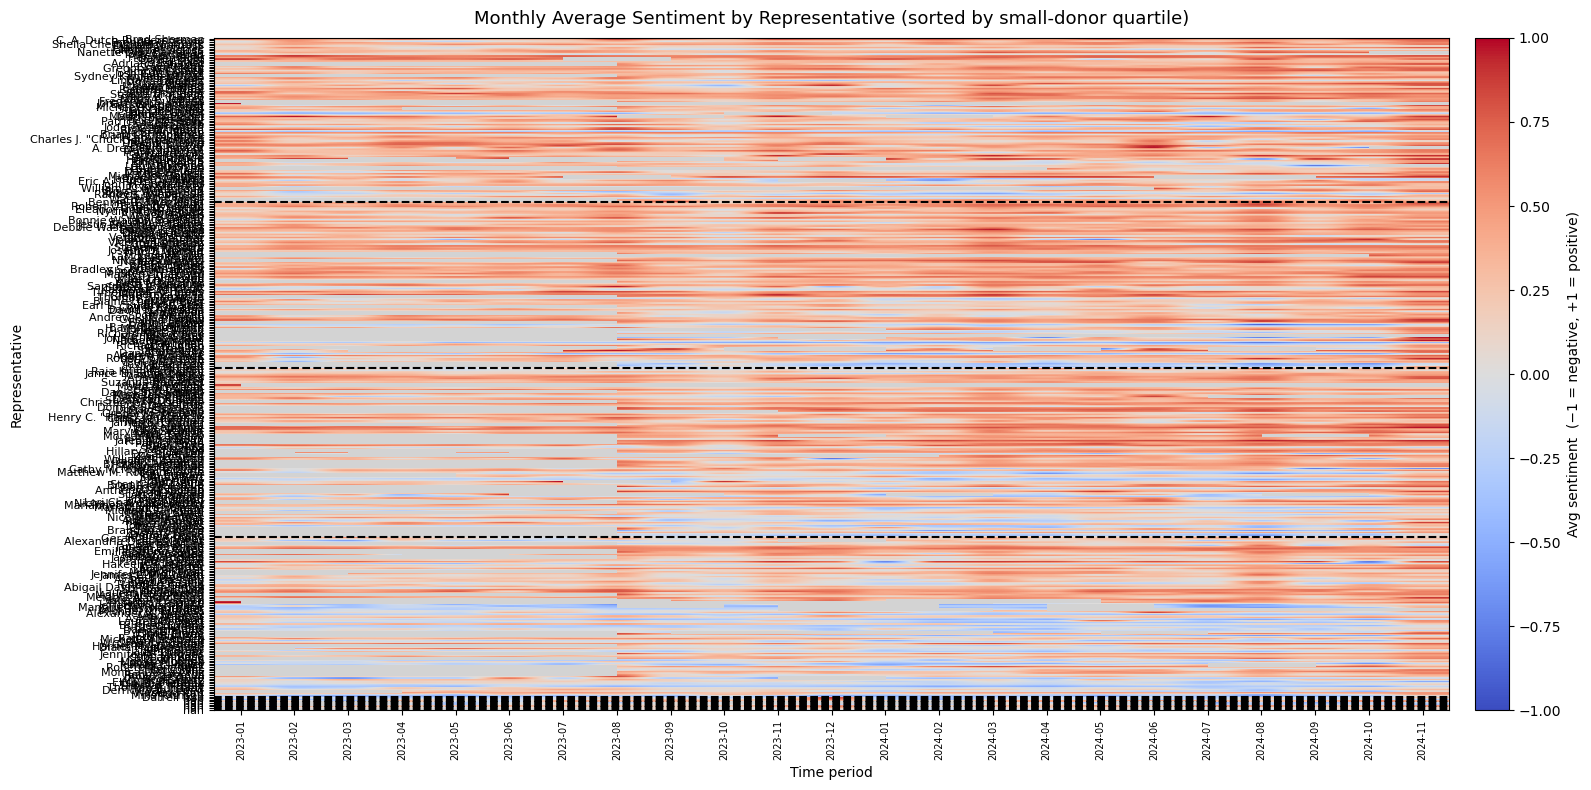

In [15]:
# ── 6a · Sentiment heatmap ──────────────────────────────────────────────────

tweets["period"] = tweets["Created At"].dt.to_period(TIME_FREQ)
all_periods = pd.period_range(tweets["period"].min(), tweets["period"].max(), freq=TIME_FREQ)

handle_order, name_order, q_order = quartile_sorted_order(tweets)

sent_pivot = (
    tweets.groupby(["handle", "period"])["sentiment_score"]
    .mean()
    .unstack()
    .reindex(index=handle_order, columns=all_periods)
)
sent_pivot.index = name_order   # show full names on y-axis
sent_pivot.columns = sent_pivot.columns.astype(str)

freq_label = "Monthly" if TIME_FREQ == "M" else "Quarterly"
plot_heatmap(
    sent_pivot,
    title=f"{freq_label} Average Sentiment by Representative (sorted by small-donor quartile)",
    cbar_label="Avg sentiment  (−1 = negative, +1 = positive)",
    vmin=-1, vmax=1,
    cmap_name="coolwarm",
    quartile_list=q_order,
)

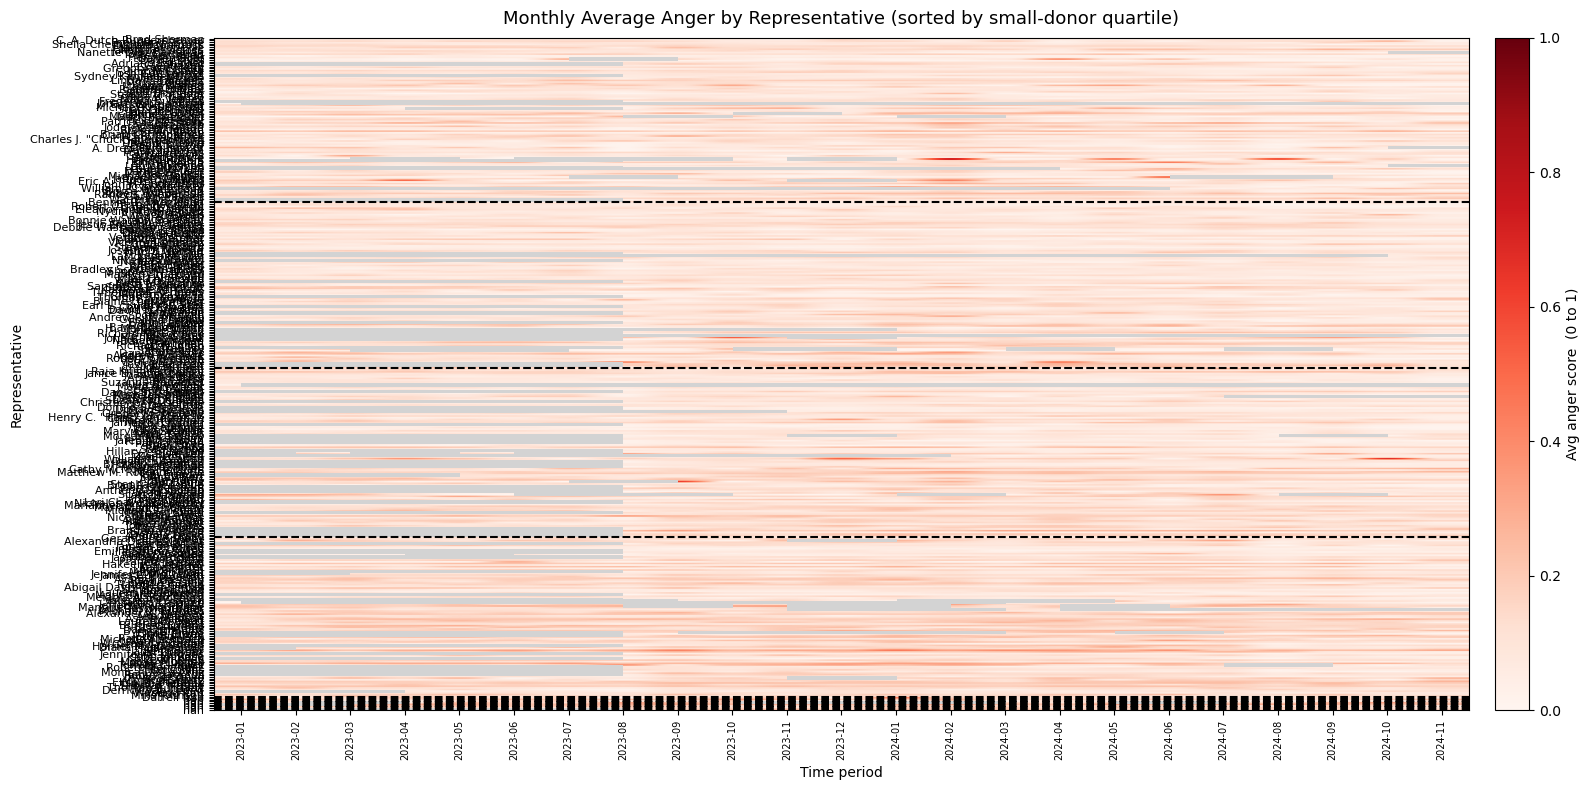

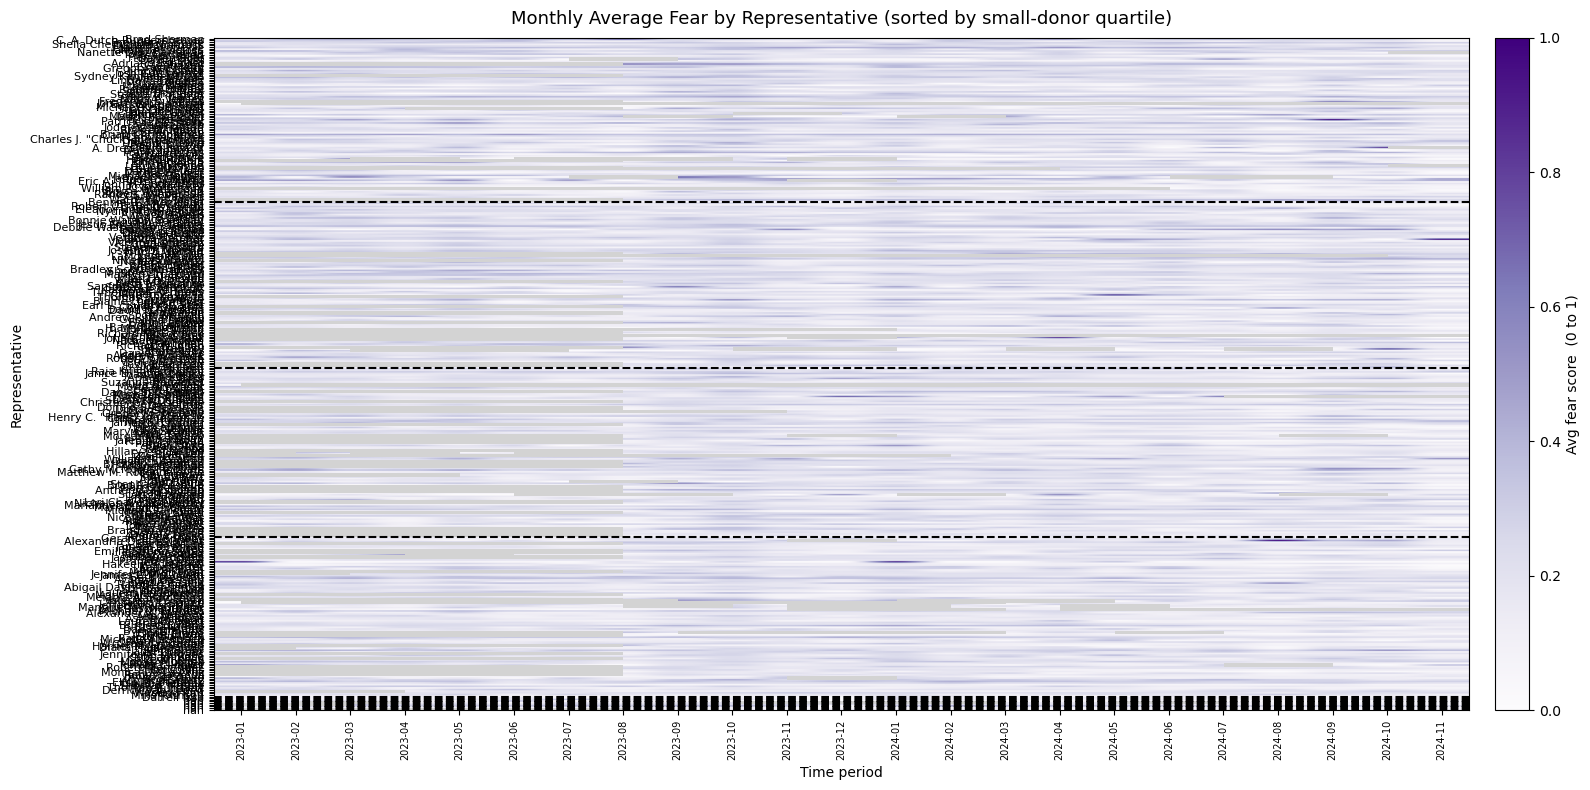

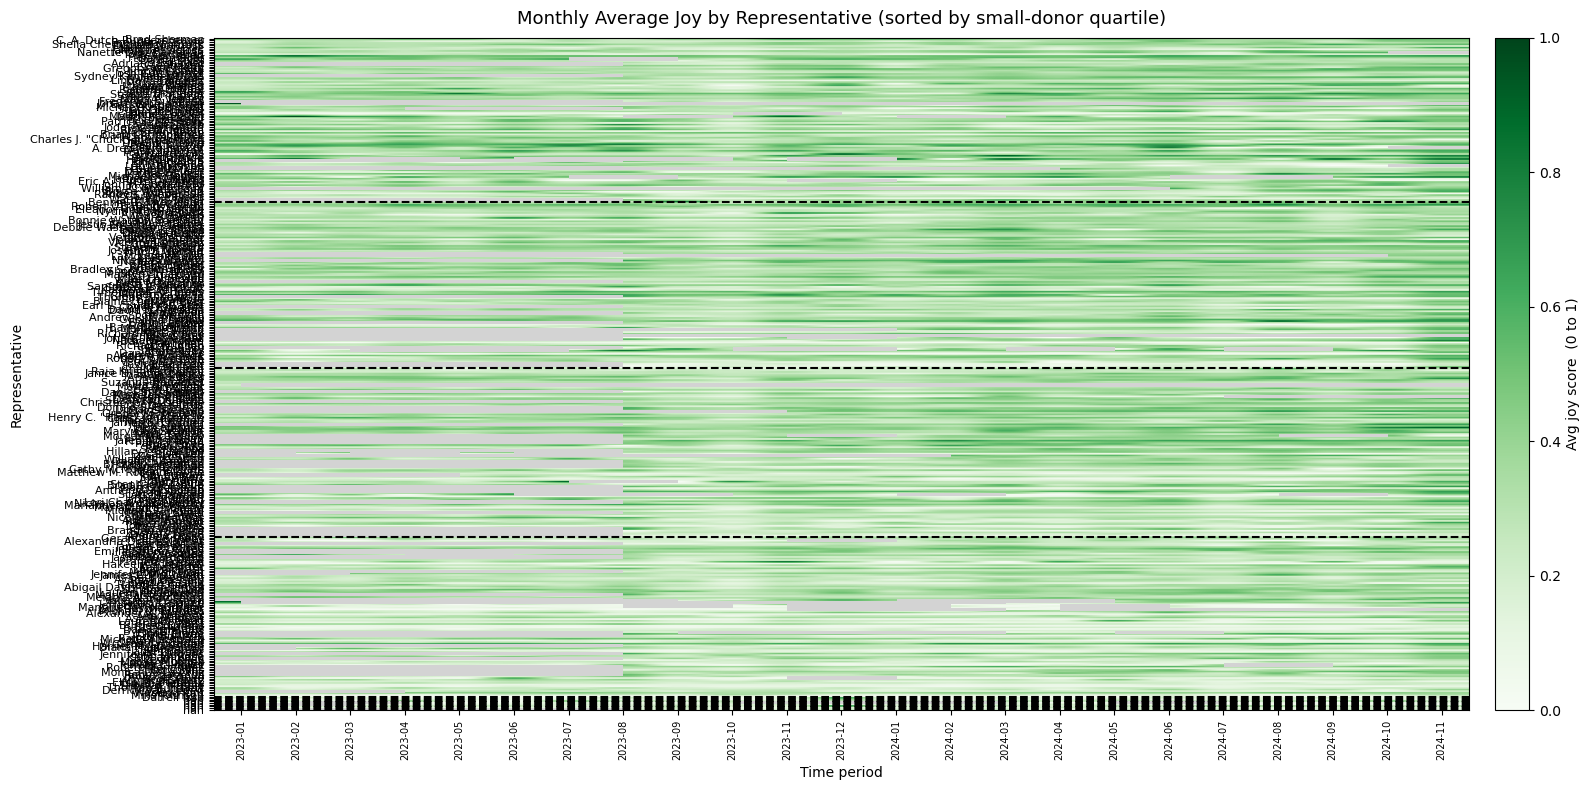

In [16]:
# ── 6b · Emotion heatmaps (anger / fear / joy) ─────────────────────────────

for emotion, cmap in [("anger", "Reds"), ("fear", "Purples"), ("joy", "Greens")]:
    emo_pivot = (
        tweets.groupby(["handle", "period"])[emotion]
        .mean()
        .unstack()
        .reindex(index=handle_order, columns=all_periods)
    )
    emo_pivot.index = name_order
    emo_pivot.columns = emo_pivot.columns.astype(str)

    plot_heatmap(
        emo_pivot,
        title=f"{freq_label} Average {emotion.title()} by Representative (sorted by small-donor quartile)",
        cbar_label=f"Avg {emotion} score  (0 to 1)",
        vmin=0, vmax=1,
        cmap_name=cmap,
        quartile_list=q_order,
    )

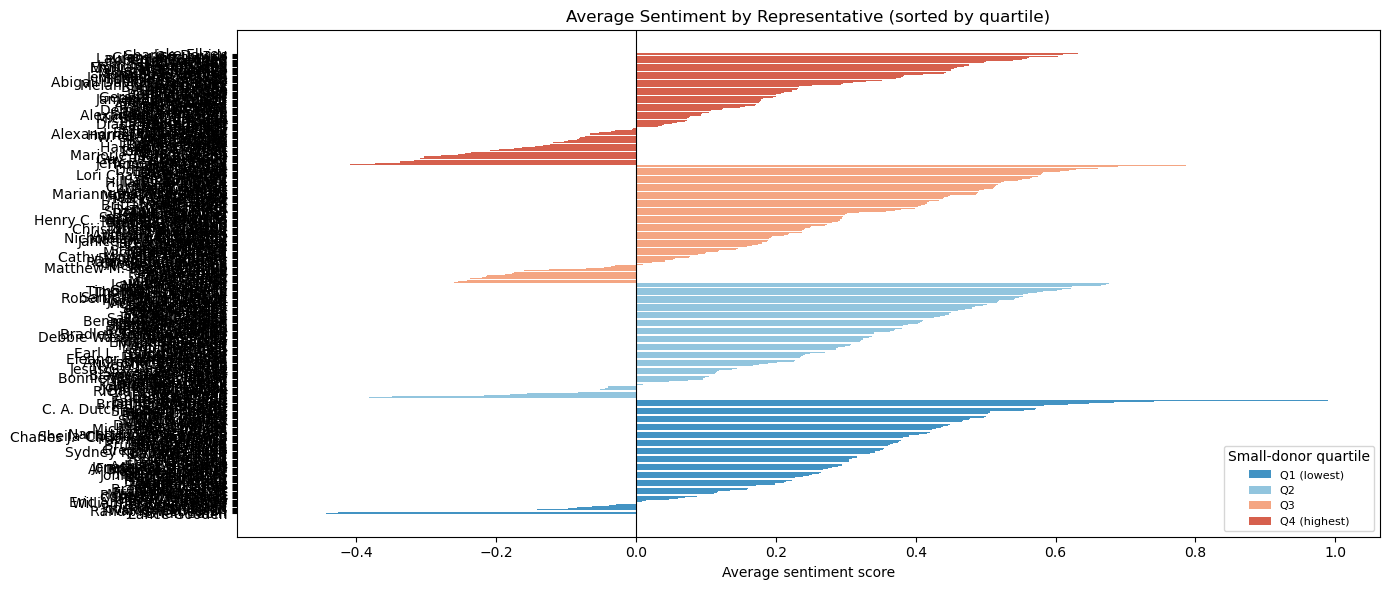

In [17]:
# ── 6c · User summary bar chart: avg sentiment by rep, coloured by quartile ─

q_colors = {
    "Q1 (lowest)":  "#4393c3",
    "Q2":           "#92c5de",
    "Q3":           "#f4a582",
    "Q4 (highest)": "#d6604d",
}

summary_sorted = (
    user_summary.copy()
    .assign(q_rank=lambda d: pd.Categorical(
        d["quartile"], categories=QUARTILE_ORDER, ordered=True))
    .sort_values(["q_rank", "avg_sentiment"])
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    summary_sorted["official_full"],
    summary_sorted["avg_sentiment"],
    color=[q_colors.get(q, "grey") for q in summary_sorted["quartile"]],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average sentiment score")
ax.set_title("Average Sentiment by Representative (sorted by quartile)")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=q) for q, c in q_colors.items()]
ax.legend(handles=legend_elements, title="Small-donor quartile",
          loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
import statsmodels.formula.api as smf

model = smf.ols("avg_sentiment ~ pct_small_donors + C(party_code)", data=user_summary).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          avg_sentiment   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     62.28
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.84e-24
Time:                        10:16:03   Log-Likelihood:                 36.048
No. Observations:                 403   AIC:                            -66.10
Df Residuals:                     400   BIC:                            -54.10
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.3959      0

In [21]:
import numpy as np
import statsmodels.formula.api as smf

engagement_summary = (
    tweets.groupby(["handle", "official_full", "quartile", "party_code", "pct_small_donors"])
    .agg(
        avg_retweets = ("Retweets", "mean"),
        avg_likes    = ("Likes",    "mean"),
        tweet_count  = ("Text",     "count"),
    )
    .reset_index()
)

engagement_summary["log_retweets"] = np.log1p(engagement_summary["avg_retweets"])
engagement_summary["log_likes"]    = np.log1p(engagement_summary["avg_likes"])

model_rt_log = smf.ols("log_retweets ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Retweets ===")
print(model_rt_log.summary())

model_lk_log = smf.ols("log_likes ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Likes ===")
print(model_lk_log.summary())

=== Log Retweets ===
                            OLS Regression Results                            
Dep. Variable:           log_retweets   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     87.97
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.17e-32
Time:                        10:18:49   Log-Likelihood:                -650.66
No. Observations:                 403   AIC:                             1307.
Df Residuals:                     400   BIC:                             1319.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept      

In [22]:
import numpy as np

engagement_summary["log_retweets"] = np.log1p(engagement_summary["avg_retweets"])
engagement_summary["log_likes"]    = np.log1p(engagement_summary["avg_likes"])

model_rt_log = smf.ols("log_retweets ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Retweets ===")
print(model_rt_log.summary())

model_lk_log = smf.ols("log_likes ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Likes ===")
print(model_lk_log.summary())

=== Log Retweets ===
                            OLS Regression Results                            
Dep. Variable:           log_retweets   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     87.97
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.17e-32
Time:                        10:18:52   Log-Likelihood:                -650.66
No. Observations:                 403   AIC:                             1307.
Df Residuals:                     400   BIC:                             1319.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept      

In [28]:
import pandas as pd

sample = pd.read_csv("sample_house_full.csv")
tweets = pd.read_csv("house_tweets_enriched.csv")

sample_handles = set(sample["twitter"].str.lower().str.strip().dropna())
tweet_handles = set(tweets["Account"].str.lower().str.strip().dropna())

matched = sample_handles & tweet_handles
print(f"Sample members: {len(sample_handles)}")
print(f"Tweet accounts: {len(tweet_handles)}")
print(f"Matched: {len(matched)}")
print(f"In sample but no tweets: {len(sample_handles - tweet_handles)}")
print(f"In tweets but not in sample: {len(tweet_handles - sample_handles)}")

/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_51985/3260022650.py:4: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  tweets = pd.read_csv("house_tweets_enriched.csv")


Sample members: 414
Tweet accounts: 411
Matched: 403
In sample but no tweets: 11
In tweets but not in sample: 8


---
## 7 · Partisanship / Extremeness Metrics

Build composite partisanship measures from existing sentiment & emotion scores.
No new model needed — these metrics are derived from the RoBERTa and Hartmann outputs.

**Metrics:**
- **Outrage index** — `avg_anger + avg_disgust` (strongest textual signal of partisan rhetoric)
- **Rhetorical intensity** — std dev of sentiment scores (wide swings = charged language)
- **Negativity rate** — proportion of tweets with negative sentiment
- **Extreme tweet share** — proportion with `|sentiment_score| > 0.8`
- **Partisanship score** — z-score composite of the above

In [ ]:
# ── Re-merge metadata (in case running from enriched CSV reload) ───────────
# This ensures official_full, quartile, party_code, pct_small_donors are present

sample = pd.read_csv(SAMPLE_HOUSE_CSV)
sample["handle_lower"] = sample["twitter"].str.lower().str.strip()
tweets["handle_lower"] = tweets["Account"].str.lower().str.strip()

meta_cols = ["handle_lower", "official_full", "quartile", "party_code", "state", "pct_small_donors"]
handle_meta = sample[meta_cols].drop_duplicates("handle_lower")

# Drop old metadata columns if they exist, then re-merge
drop_cols = [c for c in ["official_full", "quartile", "party_code", "state", "pct_small_donors"] if c in tweets.columns]
tweets = tweets.drop(columns=drop_cols, errors="ignore")
tweets = tweets.merge(handle_meta, on="handle_lower", how="inner")

tweets["pct_small_donors"] = pd.to_numeric(tweets["pct_small_donors"], errors="coerce")

print(f"Tweets after merge: {len(tweets):,}")
print(f"Unique members   : {tweets['handle_lower'].nunique()}")
print(f"\nQuartile coverage:")
print(tweets["quartile"].value_counts())

In [ ]:
# ── User-level aggregation with partisanship metrics ────────────────────────
from scipy.stats import zscore

user = (
    tweets.groupby(["handle_lower", "official_full", "quartile", "party_code", "pct_small_donors"])
    .agg(
        tweet_count    = ("sentiment_score", "count"),
        avg_sentiment  = ("sentiment_score", "mean"),
        sentiment_std  = ("sentiment_score", "std"),
        pct_negative   = ("sentiment_score", lambda x: (x < 0).mean()),
        pct_positive   = ("sentiment_score", lambda x: (x > 0).mean()),
        pct_extreme    = ("sentiment_score", lambda x: (x.abs() > 0.8).mean()),
        avg_anger      = ("anger",   "mean"),
        avg_fear       = ("fear",    "mean"),
        avg_joy        = ("joy",     "mean"),
        avg_disgust    = ("disgust", "mean"),
        avg_sadness    = ("sadness", "mean"),
    )
    .reset_index()
)

# ── Composite partisanship metrics ──────────────────────────────────────────
user["outrage_index"] = user["avg_anger"] + user["avg_disgust"]

# Z-score composite: higher = more partisan rhetoric
components = ["avg_anger", "avg_disgust", "pct_negative", "sentiment_std"]
for col in components:
    user[f"z_{col}"] = zscore(user[col], nan_policy="omit")

user["partisanship_score"] = user[[f"z_{c}" for c in components]].mean(axis=1)

print(f"Members: {len(user)}")
user.sort_values("partisanship_score", ascending=False)[
    ["official_full", "party_code", "quartile", "pct_small_donors",
     "outrage_index", "partisanship_score", "tweet_count"]
].head(20)

In [ ]:
# ── Correlations: each metric vs pct_small_donors ──────────────────────────
metrics = ["avg_sentiment", "pct_negative", "pct_extreme", "sentiment_std",
           "avg_anger", "avg_disgust", "outrage_index", "partisanship_score"]

print("Correlation with pct_small_donors:")
print("-" * 50)
for m in metrics:
    r = user["pct_small_donors"].corr(user[m])
    print(f"  {m:25s}  r = {r:+.3f}")

---
## 8 · Partisanship Regressions

Three models testing the relationship between small-donor funding and rhetorical partisanship:

1. **Bivariate** — partisanship_score ~ pct_small_donors
2. **Party-controlled** — partisanship_score ~ pct_small_donors + party
3. **Outrage as DV** — outrage_index ~ pct_small_donors + party

In [ ]:
# ── OLS regressions ────────────────────────────────────────────────────────
import statsmodels.formula.api as smf

user["is_R"] = (user["party_code"] == "R").astype(int)

# Model 1: bivariate
m1 = smf.ols("partisanship_score ~ pct_small_donors", data=user).fit()
print("MODEL 1: partisanship_score ~ pct_small_donors")
print(f"  R² = {m1.rsquared:.3f},  β = {m1.params['pct_small_donors']:.4f},  p = {m1.pvalues['pct_small_donors']:.4f}")
print()

# Model 2: controlling for party
m2 = smf.ols("partisanship_score ~ pct_small_donors + is_R", data=user).fit()
print("MODEL 2: partisanship_score ~ pct_small_donors + party")
print(f"  R² = {m2.rsquared:.3f}")
print(f"  β(pct_small_donors) = {m2.params['pct_small_donors']:.4f},  p = {m2.pvalues['pct_small_donors']:.4f}")
print(f"  β(is_R)             = {m2.params['is_R']:.4f},  p = {m2.pvalues['is_R']:.4f}")
print()

# Model 3: outrage_index as DV
m3 = smf.ols("outrage_index ~ pct_small_donors + is_R", data=user).fit()
print("MODEL 3: outrage_index ~ pct_small_donors + party")
print(f"  R² = {m3.rsquared:.3f}")
print(f"  β(pct_small_donors) = {m3.params['pct_small_donors']:.4f},  p = {m3.pvalues['pct_small_donors']:.4f}")
print(f"  β(is_R)             = {m3.params['is_R']:.4f},  p = {m3.pvalues['is_R']:.4f}")
print()

print("=" * 70)
print("FULL SUMMARY — Model 2 (party-controlled partisanship)")
print("=" * 70)
print(m2.summary())

In [ ]:
# ── Model 4: individual emotion components ────────────────────────────────
# Which emotions drive the relationship?

for emotion in ["avg_anger", "avg_fear", "avg_joy", "avg_disgust", "avg_sadness"]:
    m = smf.ols(f"{emotion} ~ pct_small_donors + is_R", data=user).fit()
    beta = m.params['pct_small_donors']
    p = m.pvalues['pct_small_donors']
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {emotion:15s}  β = {beta:+.5f}  p = {p:.4f}  R² = {m.rsquared:.3f}  {sig}")

---
## 9 · Partisanship Visualizations

In [ ]:
# ── 9a · Scatter: small donor % vs partisanship score ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label in zip(axes,
    ["partisanship_score", "outrage_index"],
    ["Partisanship Score (z-composite)", "Outrage Index (anger + disgust)"]):

    for party, color, marker in [("D", "#2166ac", "o"), ("R", "#b2182b", "s")]:
        mask = user["party_code"] == party
        ax.scatter(user.loc[mask, "pct_small_donors"], user.loc[mask, metric],
                   c=color, marker=marker, alpha=0.5, s=30, label=party)

    # Regression line (all members)
    valid = user[["pct_small_donors", metric]].dropna()
    z = np.polyfit(valid["pct_small_donors"], valid[metric], 1)
    x_line = np.linspace(valid["pct_small_donors"].min(), valid["pct_small_donors"].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "k--", alpha=0.5, label="OLS fit")

    ax.set_xlabel("Small Donor %")
    ax.set_ylabel(label)
    ax.legend()

fig.suptitle("Small Donor Share vs. Rhetorical Partisanship (House Members)", fontsize=13)
plt.tight_layout()
plt.savefig("partisanship_vs_small_donors.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 9b · Box plots: partisanship by quartile ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

q_order = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]

for ax, metric, label in zip(axes,
    ["partisanship_score", "outrage_index"],
    ["Partisanship Score", "Outrage Index"]):

    data_by_q = [user.loc[user["quartile"] == q, metric].dropna() for q in q_order]
    bp = ax.boxplot(data_by_q, labels=q_order, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))

    colors = ["#d1e5f0", "#92c5de", "#f4a582", "#ca0020"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)

    ax.set_ylabel(label)
    ax.set_xlabel("Small Donor Quartile")
    ax.set_title(f"{label} by Quartile")

plt.tight_layout()
plt.savefig("partisanship_by_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 9c · Top 20 most partisan members ──────────────────────────────────────
top20 = user.nlargest(20, "partisanship_score").copy()
top20 = top20.sort_values("partisanship_score")

colors = top20["party_code"].map({"R": "#b2182b", "D": "#2166ac", "I": "#636363"}).values

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20["official_full"], top20["partisanship_score"], color=colors)
ax.set_xlabel("Partisanship Score (z-composite)")
ax.set_title("Top 20 Most Partisan House Members (by tweet rhetoric)")

# Add quartile labels
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row["partisanship_score"] + 0.02, i,
            f"{row['quartile']}  ({row['pct_small_donors']:.0f}%)",
            va="center", fontsize=8, color="#555555")

plt.tight_layout()
plt.savefig("top20_partisan.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 9d · Emotion profile comparison: Q4 vs Q1 ──────────────────────────────
emotions = ["avg_anger", "avg_fear", "avg_joy", "avg_disgust", "avg_sadness"]
emotion_labels = ["Anger", "Fear", "Joy", "Disgust", "Sadness"]

q1 = user[user["quartile"] == "Q1 (lowest)"][emotions].mean()
q4 = user[user["quartile"] == "Q4 (highest)"][emotions].mean()

x = np.arange(len(emotions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, q1.values, width, label="Q1 (lowest small donor %)", color="#d1e5f0")
bars2 = ax.bar(x + width/2, q4.values, width, label="Q4 (highest small donor %)", color="#ca0020", alpha=0.8)

ax.set_ylabel("Mean Emotion Score")
ax.set_title("Emotion Profile: Q1 (lowest small donor %) vs Q4 (highest)")
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels)
ax.legend()

plt.tight_layout()
plt.savefig("emotion_q1_vs_q4.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Save user-level data with partisanship metrics ─────────────────────────
user.to_csv("user_partisanship_summary.csv", index=False)
print(f"Saved → user_partisanship_summary.csv  ({len(user)} members)")
print(f"\nColumns: {user.columns.tolist()}")